4. Extend Grover’s algorithm for a 3-qubit oracle and analyze iterations.

In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b102ed6fd50c11534eac822d67c93769ea9bf2a5ced7949dcdac6750dad1df44
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc



Iterations: 1
Counts: {'100': 31, '001': 36, '110': 26, '011': 38, '111': 29, '010': 35, '000': 47, '101': 782}
Probability of 101: 0.764

Iterations: 2
Counts: {'000': 5, '010': 7, '100': 7, '001': 9, '110': 6, '111': 12, '011': 5, '101': 973}
Probability of 101: 0.950

Iterations: 3
Counts: {'110': 94, '000': 99, '010': 115, '001': 97, '101': 316, '100': 105, '011': 98, '111': 100}
Probability of 101: 0.309




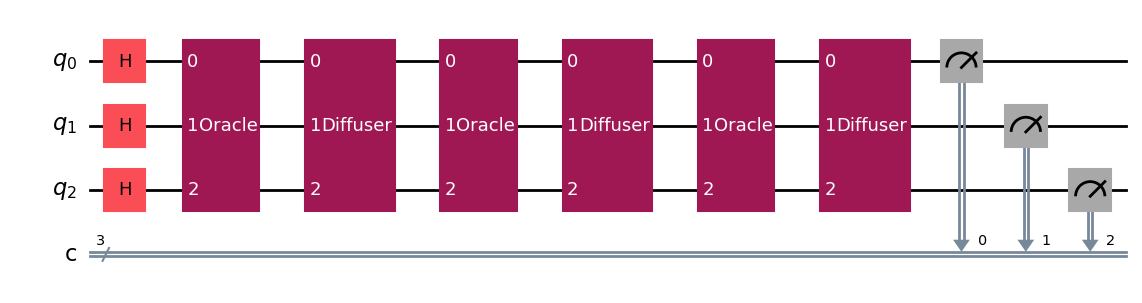

In [4]:
#4. Extend Grover’s algorithm for a 3-qubit oracle and analyze iterations

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
import math

def create_oracle():
    qc = QuantumCircuit(3)

    # Mark |101> → q2 q1 q0
    qc.x(1)
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    qc.x(1)

    return qc.to_gate(label="Oracle")

def create_diffuser():
    qc = QuantumCircuit(3)

    qc.h([0, 1, 2])
    qc.x([0, 1, 2])

    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)

    qc.x([0, 1, 2])
    qc.h([0, 1, 2])

    return qc.to_gate(label="Diffuser")

simulator = Aer.get_backend('qasm_simulator')

target = "101"

for iterations in range(1, 4):
    qc = QuantumCircuit(3, 3)

    # Superposition
    qc.h([0, 1, 2])

    # Grover iterations
    for _ in range(iterations):
        qc.append(create_oracle(), [0, 1, 2])
        qc.append(create_diffuser(), [0, 1, 2])

    # Measurement
    qc.measure([0, 1, 2], [0, 1, 2])

    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1024).result()
    counts = result.get_counts()

    prob = counts.get(target, 0) / 1024

    print(f"\nIterations: {iterations}")
    print("Counts:", counts)
    print(f"Probability of {target}: {prob:.3f}")
print('\n')
qc.draw('mpl')